# Explicabilidad de modelos de Machine Learning

Muchos modelos modernos de Machine Learning (Random Forest, Gradient Boosting, Redes Neuronales Artificiales, SVM con kernel) pueden alcanzar niveles de precisión altos, pero son difíciles de interpretar. Este hecho plantea problemas para aplicaciones en campos como la medicina, las finanzas, la seguridad y otros sistemas críticos, incluso, existen **normativas internacionales** que exigen a los diseñadores de aplicaciones que basadas en IA/ML poder responder a preguntas como:

- ¿Por qué el modelo tomó esta decisión?

- ¿Qué variables fueron más importantes?

- ¿Qué pasaría si cambiamos una característica?

## Tipos de explicabilidad

**Según el alcance**

- Global: comportamiento general del modelo (similar a las técnicas que estiman la importancia de variables)

- Local: explicación de una predicción concreta

**Según el modelo**

- Model-specific: dependen del modelo (árboles, redes)

- Model-agnostic: aplicables a cualquier modelo

**Contrafactual**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Cargar datos
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Modelo
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## SHAP Values

SHAP (SHapley Additive exPlanations) [1] se basa en la teoría de juegos cooperativos. Cada variable es vista como un jugador que contribuye a la predicción final, la cual se descompone como:

$$f({\bf{x}}) = \phi_0 + \sum_{i=1}^{d} \phi_i({\bf{x}})$$

donde

- $\phi_0 = \mathbb{E}[f(X)]$ es el baseline (predicción media del modelo)
- $\phi_i({\bf{x}})$ es la contribución local de la característica $i$

La contribución $\phi_i({\bf{x}})$ se estima como:

$$\phi_i({\bf{x}}) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! \, (d - |S| - 1)!}{d!} \left[ f_{S \cup \{i\}}({\bf{x}}) - f_S({\bf{x}}) \right]$$

donde

- $N = \{1, \dots, d\}$ el conjunto de características

- $S \subseteq N \setminus \{i\}$ un subconjunto de características

- $f_S(x)$ el modelo evaluado usando solo las características en $S$.


In [3]:
import shap

In [4]:
y_est = model.predict(X_test)

# Inicializar explicador
explainer = shap.TreeExplainer(model)

# Calcular SHAP values
shap_values = explainer(X_test)

### Explicación global

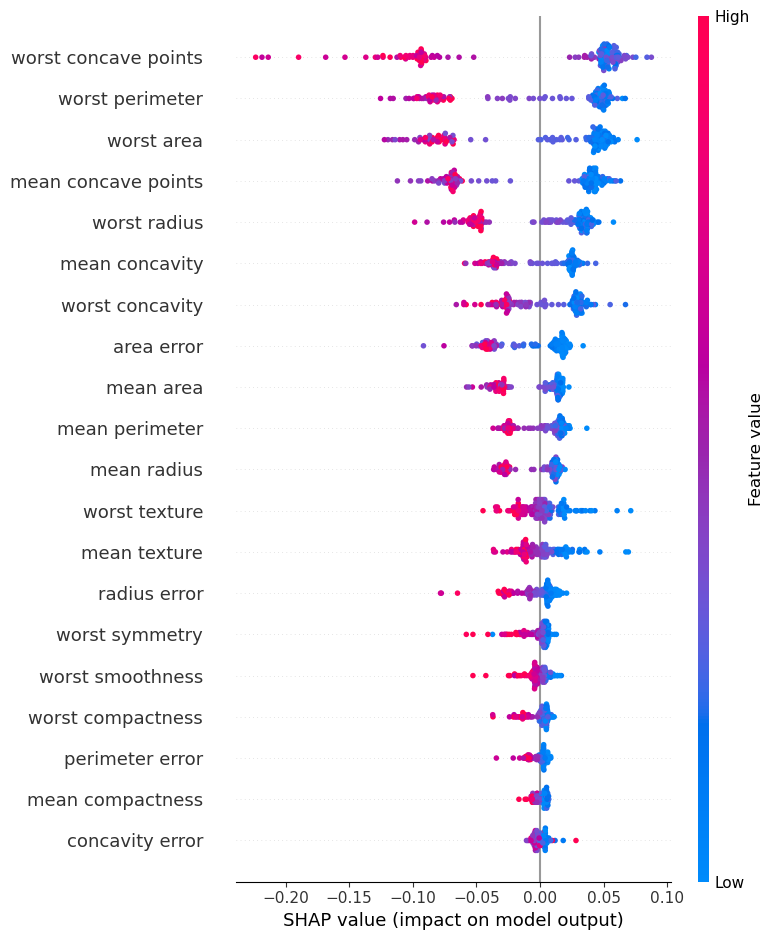

In [5]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test
)

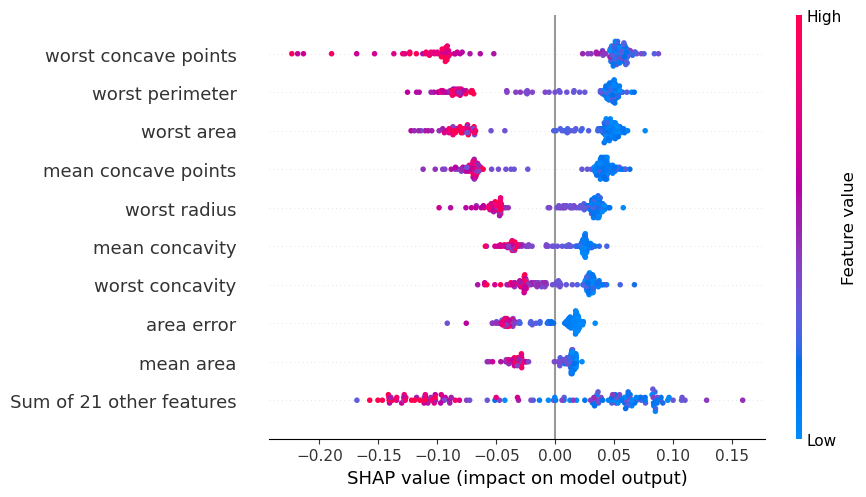

In [6]:
shap.plots.beeswarm(shap_values[:,:,1])

### Explicación local: una observación

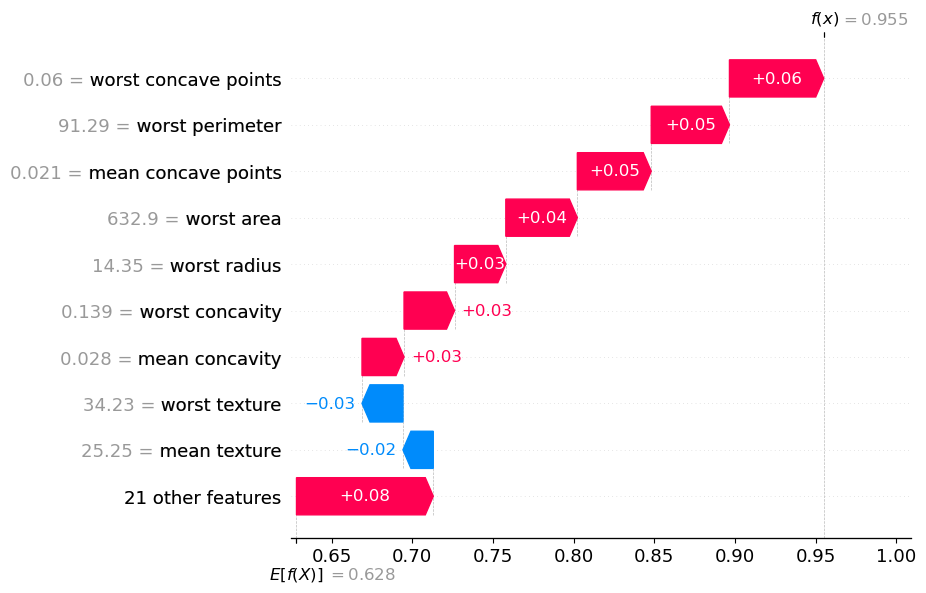

In [7]:
i = 10
shap.plots.waterfall(shap_values[i,:,y_est[i]])

In [8]:
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values.values[i,:,1],X.iloc[i,:], plot_cmap="DrDb")

## LIME

LIME (Local Interpretable Model-agnostic Explanations) [2] explica una predicción local aproximando el modelo complejo por un modelo simple local. El procedimiento que sigue LIMe es el siguiente:

- Dada una muestra $\bf{x}$, genera un conjunto de datos "falso", aplicando ligeras perturbaciones aleatorias a las características de la muestra.
- Estima un peso para cada una de las muestras falsas con base en la distancia a la muestra original.
- Para cada una de las muestras generadas, obtiene las predicciones del modelo entrenado previamente.
- Entrena un modelo sustituto simple, por ejemplo, una regresión lineal, y los pesos asignados por el modelo durante el entrenamiento son usados como medidas que explican la importancia de las variables en la predicción.

In [9]:
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display

In [10]:
explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=["maligno", "benigno"],
    mode="classification"
)

In [11]:
exp = explainer_lime.explain_instance(
    X_test.iloc[i].values,
    model.predict_proba,
    num_features=8
)

exp.show_in_notebook()

/Users/jdariasl/miniconda3/envs/pytorch/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Explicabilidad contrafactual


Las técnicas anteriores ayudan a respondera la pregunta de ¿porqué el modelo tomo una decisión en particular? La explicabiliad contrafactual ayuda a responder a la pregunta de **¿Qué pasaría si?** y más precisamente, **¿Qué debemos cambiar para obtener un resultado diferente?**

Es necesario tener en cuenta:

- Rangos dinámicos de las variables factibles
- Variables inmutables
- Objetivos: Proveer una variedad de posibles soluciones, encontrar la solución más cercana que provee un resultado contrario o la que cambie el menor número de características.


In [1]:
import kagglehub
# Download latest version
path = kagglehub.competition_download('GiveMeSomeCredit')

print("Path to competition files:", path)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 5.16M/5.16M [00:04<00:00, 1.13MB/s]

Extracting files...


Path to competition files: /Users/jdariasl/.cache/kagglehub/competitions/GiveMeSomeCredit


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

In [2]:
# ── Colour palette ────────────────────────────────────────────────────────────
C_BAD   = "#E74C3C"   # high-risk / negative class
C_GOOD  = "#2ECC71"   # low-risk  / positive class
C_NEUT  = "#3498DB"   # neutral / informational
C_DARK  = "#1A1A2E"   # background / dark text
C_LIGHT = "#F7F9FC"   # panel background

plt.rcParams.update({
    "figure.facecolor": C_LIGHT,
    "axes.facecolor":   C_LIGHT,
    "axes.edgecolor":   "#CCCCCC",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "font.family":      "DejaVu Sans",
    "text.color":       C_DARK,
})

#── Load data ────
df = pd.read_csv("/Users/jdariasl/.cache/kagglehub/competitions/GiveMeSomeCredit/cs-training.csv").dropna()

FEATURE_NAMES = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents",
]

SHORT_NAMES = [
    "Revolving Util.",
    "Age",
    "Late 30-59 days",
    "Debt Ratio",
    "Monthly Income",
    "Open Credit Lines",
    "90+ Days Late",
    "Real Estate Loans",
    "Late 60-89 days",
    "Dependents",
]


X  = df[FEATURE_NAMES].values
y  = df["SeriousDlqin2yrs"].values

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2. TRAIN / TEST SPLIT & MODEL
# ═══════════════════════════════════════════════════════════════════════════════
print("▶  Training Random Forest classifier …")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)
model.fit(X_train, y_train)

y_pred      = model.predict(X_test)
y_prob      = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)
cm          = confusion_matrix(y_test, y_pred, normalize='true')

print(f"   AUC-ROC : {roc_auc:.3f}")
print(classification_report(y_test, y_pred, target_names=["Low Risk","High Risk"]))

▶  Training Random Forest classifier …
   AUC-ROC : 0.849
              precision    recall  f1-score   support

    Low Risk       0.98      0.80      0.88     27979
   High Risk       0.22      0.73      0.34      2089

    accuracy                           0.80     30068
   macro avg       0.60      0.77      0.61     30068
weighted avg       0.92      0.80      0.84     30068



▶  Generating plots …


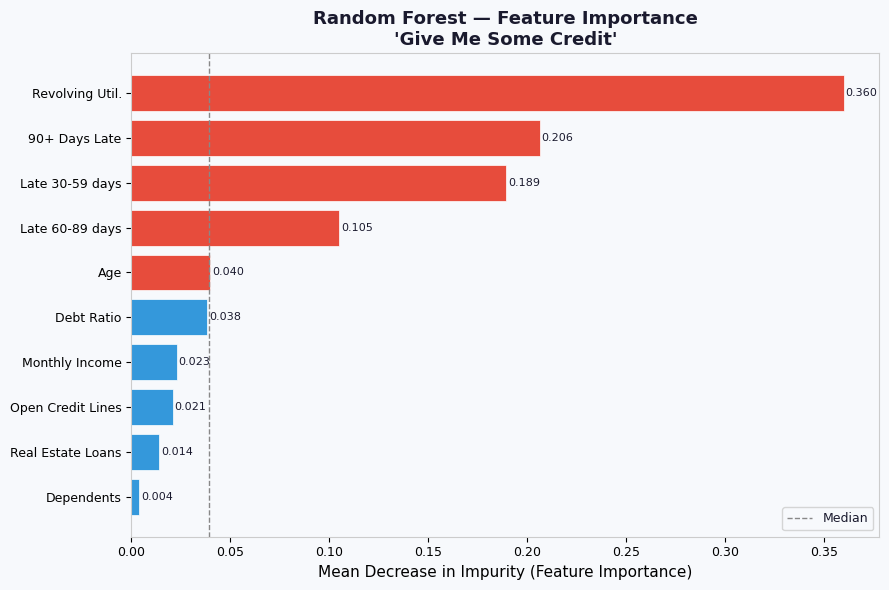

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4. PLOTS
# ═══════════════════════════════════════════════════════════════════════════════
print("▶  Generating plots …")

# ── Helper ────────────────────────────────────────────────────────────────────
def save(fig, name):
    fig.savefig(f"/Users/jdariasl/Downloads/{name}", dpi=150, bbox_inches="tight")
    print(f"   Saved → {name}")

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — Feature Importance
# ─────────────────────────────────────────────────────────────────────────────
importances = model.feature_importances_
order = np.argsort(importances)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    [SHORT_NAMES[i] for i in order],
    importances[order],
    color=[C_BAD if importances[i] > np.median(importances) else C_NEUT for i in order],
    edgecolor="white", linewidth=0.5,
)
ax.set_xlabel("Mean Decrease in Impurity (Feature Importance)")
ax.set_title("Random Forest — Feature Importance\n'Give Me Some Credit'", fontweight="bold")
ax.axvline(np.median(importances), color="#888", linestyle="--", linewidth=1, label="Median")
ax.legend(fontsize=9)
for bar, val in zip(bars, importances[order]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8)
fig.tight_layout()
#save(fig, "01_feature_importance.png")
#plt.close(fig)

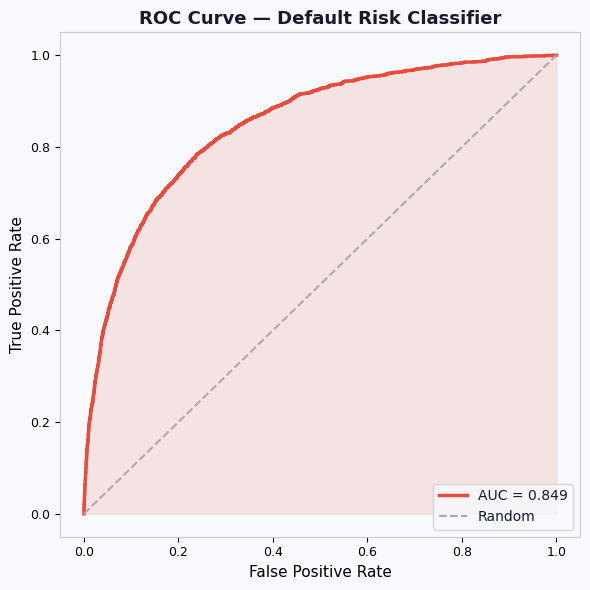

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — ROC Curve
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color=C_BAD, lw=2.5, label=f"AUC = {roc_auc:.3f}")
ax.fill_between(fpr, tpr, alpha=0.12, color=C_BAD)
ax.plot([0,1],[0,1], "--", color="#AAAAAA", lw=1.5, label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Default Risk Classifier", fontweight="bold")
ax.legend(loc="lower right")
fig.tight_layout()
#save(fig, "02_roc_curve.png")
#plt.close(fig)


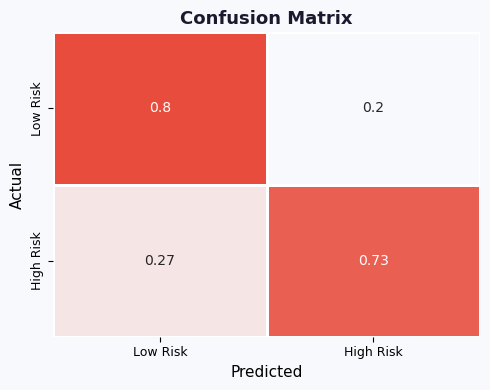

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — Confusion Matrix
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cmap = LinearSegmentedColormap.from_list("risk", [C_LIGHT, C_BAD])
sns.heatmap(cm, annot=True, cmap=cmap, ax=ax,
            xticklabels=["Low Risk","High Risk"],
            yticklabels=["Low Risk","High Risk"],
            linewidths=1, linecolor="white", cbar=False)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix", fontweight="bold")
fig.tight_layout()
#save(fig, "03_confusion_matrix.png")
#plt.close(fig)

In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3. COUNTERFACTUAL GENERATOR  (gradient-free greedy search)
# ═══════════════════════════════════════════════════════════════════════════════

def generate_counterfactual(
    model,
    instance: np.ndarray,
    feature_names: list,
    desired_class: int,
    n_iter: int = 5_000,
    step_scale: float = 0.05,
    feature_ranges: dict = None,
    inmutable_features = {},
):
    """
    Greedy random-walk counterfactual search.

    At each iteration a random feature is perturbed slightly.
    The perturbation is kept only if it moves the predicted
    probability closer to the desired class.
    Returns the counterfactual array and a per-feature delta dict.
    """
    rng = np.random.RandomState(SEED)
    cf  = instance.copy().astype(float)
    mutable_idx = [
    i for i, f in enumerate(feature_names)
    if f not in inmutable_features
    ]
    target_prob = model.predict_proba(cf.reshape(1, -1))[0, desired_class]

    for _ in range(n_iter):
        #idx   = rng.randint(0, len(cf))
        idx = rng.choice(mutable_idx)
        #delta = rng.randn() * step_scale * (abs(cf[idx]) + 1e-3)

        sign = direction_map[idx]

        delta = (
            abs(rng.randn())
            * step_scale
            * (abs(cf[idx]) + 1e-3)
            * sign
        )      
        candidate      = cf.copy()
        candidate[idx] += delta

        # Clip to allowed range if supplied
        if feature_ranges and feature_names[idx] in feature_ranges:
            lo, hi = feature_ranges[feature_names[idx]]
            candidate[idx] = np.clip(candidate[idx], lo, hi)

        new_prob = model.predict_proba(candidate.reshape(1, -1))[0, desired_class]
        if new_prob > target_prob:
            cf         = candidate
            target_prob = new_prob

        # Early stop once the model flips
        if model.predict(cf.reshape(1, -1))[0] == desired_class:
            break

    changes = {feature_names[i]: cf[i] - instance[i] for i in range(len(instance))}
    return cf, changes

# Feature value ranges (for clipping)
RANGES = {
    "RevolvingUtilizationOfUnsecuredLines": (0, 1),
    "age":                                  (18, 90),
    "NumberOfTime30-59DaysPastDueNotWorse": (0, 20),
    "DebtRatio":                            (0, 1),
    "MonthlyIncome":                        (1_000, 1_000_000),
    "NumberOfOpenCreditLinesAndLoans":      (0, 30),
    "NumberOfTimes90DaysLate":              (0, 20),
    "NumberRealEstateLoansOrLines":         (0, 10),
    "NumberOfTime60-89DaysPastDueNotWorse": (0, 20),
    "NumberOfDependents":                   (0, 10),
}

direction_map = {
    0: -1,  # RevolvingUtilization -> lower is better
    1: +1,  # age -> higher is better
    2: -1,  # late30_59 -> lower is better
    3: -1,  # DebtRatio -> lower is better
    4: +1,  # income -> higher is better
    5: +1,  # open credit lines -> slightly higher better
    6: -1,  # late90 -> lower is better
    7:  0,  # real estate loans
    8: -1,  # late60_89 -> lower is better
    9: -1,  # dependents -> lower financial burden
}

# Pick 5 high-risk instances from the test set
high_risk_idx = np.where((y_test == 1) & (y_pred == 1))[0][:5]
instances     = X_test[high_risk_idx]

print("▶  Generating counterfactuals for 5 high-risk test instances …")
cfs_list     = []
changes_list = []
for inst in instances:
    cf, changes = generate_counterfactual(
        model, inst, FEATURE_NAMES,
        desired_class=0,        # flip to Low Risk
        feature_ranges=RANGES,
    )
    cfs_list.append(cf)
    changes_list.append(changes)
    pred_orig = model.predict(inst.reshape(1, -1))[0]
    pred_cf   = model.predict(cf.reshape(1, -1))[0]
    print(f"   Original: {pred_orig} → Counterfactual: {pred_cf}")

# Use first instance for individual plots
instance_0 = instances[0]
cf_0       = cfs_list[0]
changes_0  = changes_list[0]

# Pre-compute probabilities for instance #1 (used across multiple plots)
prob_orig = model.predict_proba(instance_0.reshape(1, -1))[0, 1]
prob_cf   = model.predict_proba(cf_0.reshape(1, -1))[0, 1]

▶  Generating counterfactuals for 5 high-risk test instances …
   Original: 1 → Counterfactual: 0
   Original: 1 → Counterfactual: 0
   Original: 1 → Counterfactual: 0
   Original: 1 → Counterfactual: 0
   Original: 1 → Counterfactual: 1


In [8]:
def infer_feature_directions(model, X, feature_names, step_fraction=0.05):
    """
    Automatically infer whether increasing each feature
    tends to increase or decrease predicted risk.

    Returns
    -------
    improves_when_increased : set
        Features where increasing the value REDUCES risk.
    worsens_when_increased : set
        Features where increasing the value INCREASES risk.
    """

    improves_when_increased = set()
    worsens_when_increased = set()

    baseline_probs = model.predict_proba(X)[:, 1]

    for i, feat in enumerate(feature_names):

        X_perturbed = X.copy()

        # Small upward perturbation
        span = X[:, i].max() - X[:, i].min()
        step = span * step_fraction

        X_perturbed[:, i] += step

        perturbed_probs = model.predict_proba(X_perturbed)[:, 1]

        # Average probability shift
        mean_delta = np.mean(perturbed_probs - baseline_probs)

        print(f"{feat:45s}  Δrisk = {mean_delta:+.4f}")

        if mean_delta < 0:
            improves_when_increased.add(feat)
        else:
            worsens_when_increased.add(feat)

    return improves_when_increased, worsens_when_increased

In [9]:
improves_when_increased, worsens_when_increased = infer_feature_directions(
    model,
    X_train,
    FEATURE_NAMES
)

print("\nImproves when increased:")
print(improves_when_increased)

print("\nWorsens when increased:")
print(worsens_when_increased)

RevolvingUtilizationOfUnsecuredLines           Δrisk = +0.1886
age                                            Δrisk = -0.0094
NumberOfTime30-59DaysPastDueNotWorse           Δrisk = +0.2804
DebtRatio                                      Δrisk = +0.0367
MonthlyIncome                                  Δrisk = -0.0262
NumberOfOpenCreditLinesAndLoans                Δrisk = +0.0076
NumberOfTimes90DaysLate                        Δrisk = +0.4060
NumberRealEstateLoansOrLines                   Δrisk = +0.0217
NumberOfTime60-89DaysPastDueNotWorse           Δrisk = +0.2799
NumberOfDependents                             Δrisk = +0.0016

Improves when increased:
{'MonthlyIncome', 'age'}

Worsens when increased:
{'NumberOfDependents', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfOpenCreditLinesAndLoans', 'DebtRatio', 'NumberOfTime60-89DaysPastDueNotWorse', 'RevolvingUtilizationOfUnsecuredLines', 'NumberRealEstateLoansOrLines', 'NumberOfTimes90DaysLate'}


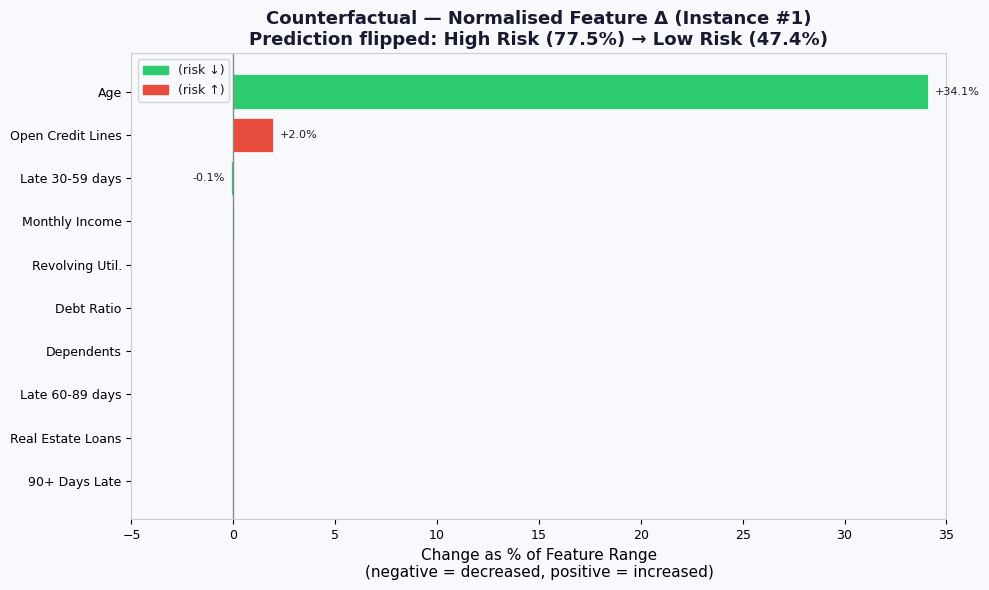

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4 — Counterfactual Delta: normalised change per feature
# Shows HOW MUCH each feature had to move (not its absolute value),
# expressed as % of the feature's range so all features are comparable.
# This is directly consistent with Plot 5 (ablation contribution).
# ─────────────────────────────────────────────────────────────────────────────
feature_ranges_span = np.array([
    X[:, i].max() - X[:, i].min() + 1e-8 for i in range(len(FEATURE_NAMES))
])
# Signed normalised delta: (cf - original) / feature_range
norm_delta = (cf_0 - instance_0)/ feature_ranges_span
 
# Sort by absolute delta so the most-changed features are prominent
order_delta = np.argsort(np.abs(norm_delta))  # ascending → largest at top when barh

colors_delta = []

for i in order_delta:
    feat = FEATURE_NAMES[i]
    d = norm_delta[i]

    if feat in improves_when_increased:
        good = d > 0
    else:
        good = d < 0

    colors_delta.append(C_GOOD if good else C_BAD)

#colors_delta = [C_GOOD if d < 0 else C_BAD for d in norm_delta[order_delta]]
# Green = feature went DOWN (risk reduced), Red = feature went UP
 
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    [SHORT_NAMES[i] for i in order_delta],
    norm_delta[order_delta] * 100,   # express as % of range
    color=colors_delta,
    edgecolor="white", linewidth=0.5,
)
ax.axvline(0, color="#888", linewidth=1)
ax.set_xlabel("Change as % of Feature Range\n(negative = decreased, positive = increased)")
ax.set_title(
    "Counterfactual — Normalised Feature Δ (Instance #1)\n"
    f"Prediction flipped: High Risk ({prob_orig:.1%}) → Low Risk ({prob_cf:.1%})",
    fontweight="bold"
)
ax.set_xlim(-5,35)
for bar, val in zip(bars, norm_delta[order_delta] * 100):
    if abs(val) > 0.1:
        ax.text(
            val + (0.3 if val >= 0 else -0.3),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}%", va="center",
            ha="left" if val >= 0 else "right", fontsize=8
        )
down_patch = mpatches.Patch(color=C_GOOD, label="(risk ↓)")
up_patch   = mpatches.Patch(color=C_BAD,  label="(risk ↑)")
ax.legend(handles=[down_patch, up_patch], fontsize=9)
fig.tight_layout()
#save(fig, "04_counterfactual_comparison.png")
#plt.close(fig)

In [18]:
print("▶  Generating counterfactuals for 5 high-risk test instances …")
cfs_list     = []
changes_list = []
for inst in instances:
    cf, changes = generate_counterfactual(
        model, inst, FEATURE_NAMES,
        desired_class=0,        # flip to Low Risk
        feature_ranges=RANGES,
        inmutable_features={"age"}
    )
    cfs_list.append(cf)
    changes_list.append(changes)
    pred_orig = model.predict(inst.reshape(1, -1))[0]
    pred_cf   = model.predict(cf.reshape(1, -1))[0]
    print(f"   Original: {pred_orig} → Counterfactual: {pred_cf}")

# Use first instance for individual plots
instance_0 = instances[0]
cf_0       = cfs_list[0]
changes_0  = changes_list[0]

# Pre-compute probabilities for instance #1 (used across multiple plots)
prob_orig = model.predict_proba(instance_0.reshape(1, -1))[0, 1]
prob_cf   = model.predict_proba(cf_0.reshape(1, -1))[0, 1]

▶  Generating counterfactuals for 5 high-risk test instances …
   Original: 1 → Counterfactual: 0
   Original: 1 → Counterfactual: 1
   Original: 1 → Counterfactual: 1
   Original: 1 → Counterfactual: 0
   Original: 1 → Counterfactual: 1


In [19]:
cf_0

array([4.76871922e-01, 5.00000000e+01, 9.24886542e-01, 4.92095433e-01,
       7.79642006e+03, 4.29634649e+00, 0.00000000e+00, 1.00000000e+00,
       0.00000000e+00, 0.00000000e+00])

In [20]:
instance_0

array([1.00994644e+00, 5.00000000e+01, 1.00000000e+00, 6.61039174e-01,
       6.10000000e+03, 4.00000000e+00, 0.00000000e+00, 1.00000000e+00,
       0.00000000e+00, 0.00000000e+00])

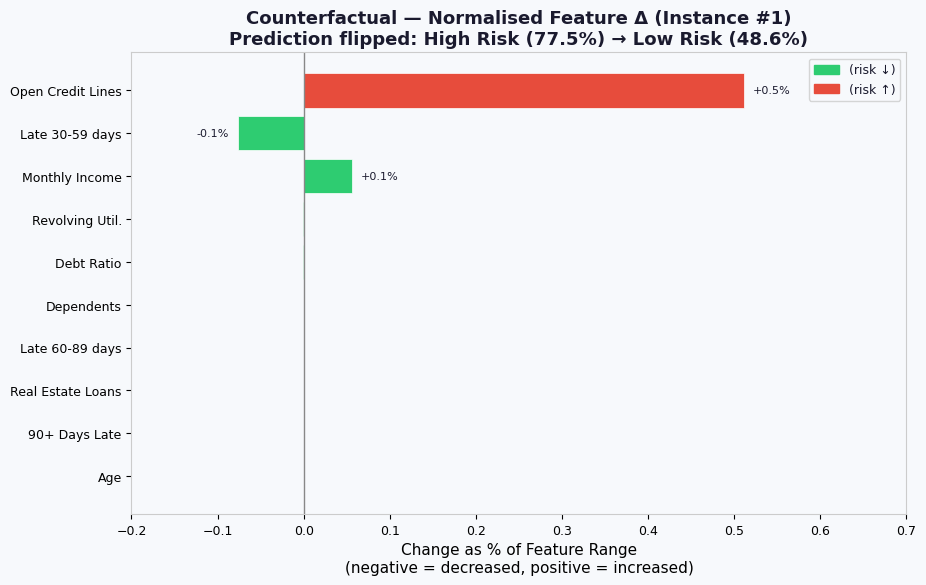

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4 — Counterfactual Delta: normalised change per feature
# Shows HOW MUCH each feature had to move (not its absolute value),
# expressed as % of the feature's range so all features are comparable.
# This is directly consistent with Plot 5 (ablation contribution).
# ─────────────────────────────────────────────────────────────────────────────
feature_ranges_span = np.array([
    X[:, i].max() - X[:, i].min() + 1e-8 for i in range(len(FEATURE_NAMES))
])
# Signed normalised delta: (cf - original) / feature_range
norm_delta = (cf_0 - instance_0)/ feature_ranges_span
 
# Sort by absolute delta so the most-changed features are prominent
order_delta = np.argsort(np.abs(norm_delta))  # ascending → largest at top when barh

colors_delta = []

for i in order_delta:
    feat = FEATURE_NAMES[i]
    d = norm_delta[i]

    if feat in improves_when_increased:
        good = d > 0
    else:
        good = d < 0

    colors_delta.append(C_GOOD if good else C_BAD)

#colors_delta = [C_GOOD if d < 0 else C_BAD for d in norm_delta[order_delta]]
# Green = feature went DOWN (risk reduced), Red = feature went UP
 
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    [SHORT_NAMES[i] for i in order_delta],
    norm_delta[order_delta] * 100,   # express as % of range
    color=colors_delta,
    edgecolor="white", linewidth=0.5,
)
ax.axvline(0, color="#888", linewidth=1)
ax.set_xlabel("Change as % of Feature Range\n(negative = decreased, positive = increased)")
ax.set_title(
    "Counterfactual — Normalised Feature Δ (Instance #1)\n"
    f"Prediction flipped: High Risk ({prob_orig:.1%}) → Low Risk ({prob_cf:.1%})",
    fontweight="bold"
)
ax.set_xlim(-0.2,0.7)
for bar, val in zip(bars, norm_delta[order_delta] * 100):
    if abs(val) > 0.01:
        ax.text(
            val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}%", va="center",
            ha="left" if val >= 0 else "right", fontsize=8
        )
down_patch = mpatches.Patch(color=C_GOOD, label="(risk ↓)")
up_patch   = mpatches.Patch(color=C_BAD,  label="(risk ↑)")
ax.legend(handles=[down_patch, up_patch], fontsize=9)
#fig.tight_layout()
#save(fig, "04_counterfactual_comparison.png")
#plt.close(fig)

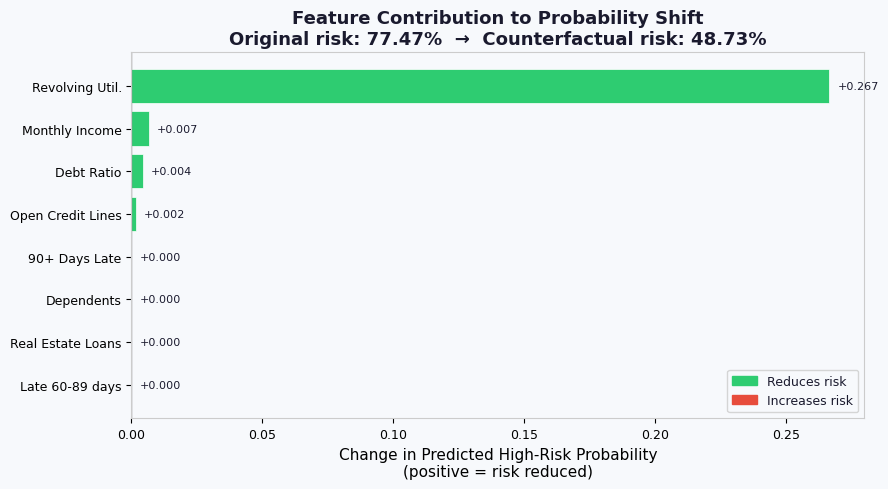

In [53]:

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 5 — Waterfall: how each feature change contributes to probability shift
# ─────────────────────────────────────────────────────────────────────────────


# Estimate per-feature contribution via ablation
contributions = []
for i in range(len(FEATURE_NAMES)):
    modified = instance_0.copy()
    modified[i] = cf_0[i]
    p = model.predict_proba(modified.reshape(1,-1))[0,1]
    contributions.append(prob_orig - p)   # positive → reduces risk

order_wf  = np.argsort(np.abs(contributions))[::-1]
top_n     = 8
idx_wf    = order_wf[:top_n]
vals_wf   = [contributions[i] for i in idx_wf]
names_wf  = [SHORT_NAMES[i]   for i in idx_wf]
colors_wf = [C_GOOD if v > 0 else C_BAD for v in vals_wf]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(names_wf[::-1], vals_wf[::-1], color=colors_wf[::-1],
               edgecolor="white", linewidth=0.5)
ax.axvline(0, color="#888", linewidth=1)
ax.set_xlabel("Change in Predicted High-Risk Probability\n(positive = risk reduced)")
ax.set_title(
    f"Feature Contribution to Probability Shift\n"
    f"Original risk: {prob_orig:.2%}  →  Counterfactual risk: {prob_cf:.2%}",
    fontweight="bold"
)
for bar, val in zip(bars, vals_wf[::-1]):
    ax.text(val + (0.003 if val >= 0 else -0.003),
            bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)
good_patch = mpatches.Patch(color=C_GOOD, label="Reduces risk")
bad_patch  = mpatches.Patch(color=C_BAD,  label="Increases risk")
ax.legend(handles=[good_patch, bad_patch], fontsize=9)
fig.tight_layout()
#save(fig, "05_waterfall_contribution.png")
#plt.close(fig)


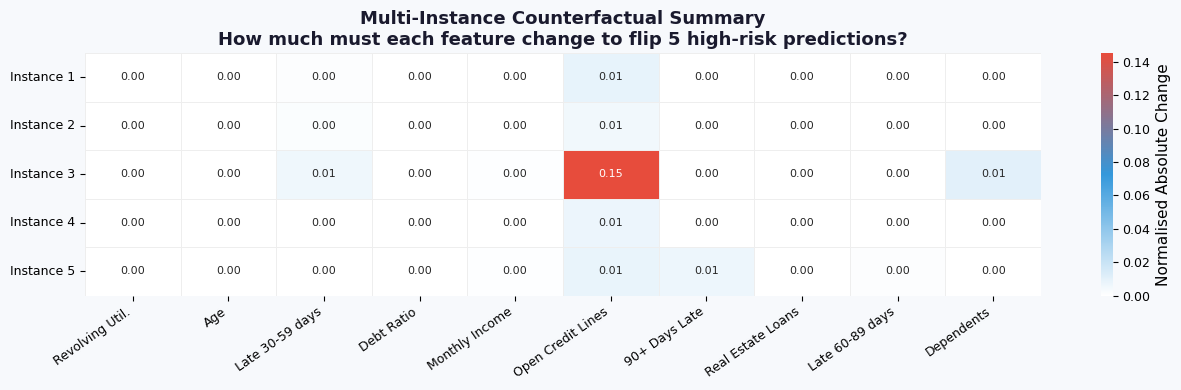

In [54]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 6 — Multi-instance Counterfactual Summary Heatmap
# ─────────────────────────────────────────────────────────────────────────────
# Collect normalised absolute changes for 5 instances
heatmap_data = np.zeros((5, len(FEATURE_NAMES)))
for j, (inst, cf) in enumerate(zip(instances, cfs_list)):
    for i in range(len(FEATURE_NAMES)):
        span = X[:, i].max() - X[:, i].min() + 1e-8
        heatmap_data[j, i] = abs(cf[i] - inst[i]) / span

fig, ax = plt.subplots(figsize=(13, 4))
cmap_hm = LinearSegmentedColormap.from_list("cf", ["#FFFFFF", C_NEUT, C_BAD])
sns.heatmap(heatmap_data,
            xticklabels=SHORT_NAMES,
            yticklabels=[f"Instance {i+1}" for i in range(5)],
            cmap=cmap_hm, ax=ax,
            linewidths=0.5, linecolor="#EEE",
            annot=True, fmt=".2f", annot_kws={"size": 8},
            cbar_kws={"label": "Normalised Absolute Change"})
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_title("Multi-Instance Counterfactual Summary\n"
             "How much must each feature change to flip 5 high-risk predictions?",
             fontweight="bold")
fig.tight_layout()
#save(fig, "06_counterfactual_heatmap.png")
#plt.close(fig)


✅  All plots saved to /mnt/user-data/outputs/

Summary


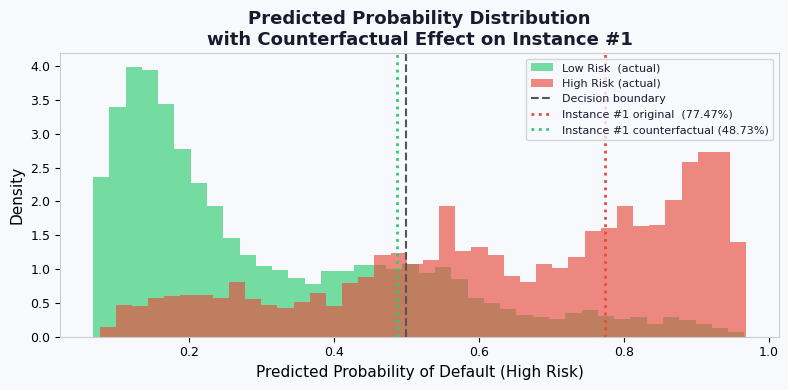

In [55]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 7 — Probability Distribution with counterfactual threshold marker
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
probs_low  = y_prob[y_test == 0]
probs_high = y_prob[y_test == 1]
ax.hist(probs_low,  bins=40, color=C_GOOD, alpha=0.65, label="Low Risk  (actual)", density=True)
ax.hist(probs_high, bins=40, color=C_BAD,  alpha=0.65, label="High Risk (actual)", density=True)
ax.axvline(0.5, color="#555", linewidth=1.5, linestyle="--", label="Decision boundary")
ax.axvline(prob_orig, color=C_BAD,  linewidth=2, linestyle=":",
           label=f"Instance #1 original  ({prob_orig:.2%})")
ax.axvline(prob_cf,   color=C_GOOD, linewidth=2, linestyle=":",
           label=f"Instance #1 counterfactual ({prob_cf:.2%})")
ax.set_xlabel("Predicted Probability of Default (High Risk)")
ax.set_ylabel("Density")
ax.set_title("Predicted Probability Distribution\nwith Counterfactual Effect on Instance #1",
             fontweight="bold")
ax.legend(fontsize=8)
fig.tight_layout()
#save(fig, "07_probability_distribution.png")
#plt.close(fig)

print("\n✅  All plots saved to /mnt/user-data/outputs/")
print("\nSummary")